# 🏦 ClearBank — Análise Financeira de Transações
**Desafio Final | Módulo Python para Análise de Dados**

Pipeline completo de análise de transações bancárias:

| Etapa | Descrição |
|-------|-----------|
| **R1** | Leitura do CSV com módulo nativo (`csv.DictReader`) |
| **R2** | Validação e limpeza dos dados (5 regras, `try/except`) |
| **R3** | Organização em funções com responsabilidade única |
| **R4** | Manipulação de datas com `datetime` |
| **R5** | Agrupamento mensal e métricas financeiras |
| **R6** | Identificação de transações suspeitas |
| **R7** | Exportação do relatório em `relatorio.json` |
| **R8** | Tratamento de erros com `try/except` em ≥ 3 situações |
| **R9** | Exibição formatada no terminal |
| **RO1** | Análise alternativa com **pandas** |
| **RO2** | Visualização com **matplotlib** → `grafico.png` |

> **Pré-requisito:** o arquivo `transacoes.csv` deve estar na mesma pasta do notebook.  
> Estrutura esperada: `id, data, cliente_id, tipo, valor, descricao, categoria`  
> O CSV deve conter ≥ 15 registros válidos em ≥ 3 meses, ≥ 5 inválidos e ≥ 2 suspeitas (valor > R$ 10.000).


## 📦 1. Importações e Constantes

In [1]:
import csv
import json
import os
from datetime import datetime
from collections import defaultdict

# ── Constantes ─────────────────────────────────────────────────────────────
ARQUIVO_CSV   = "transacoes.csv"
ARQUIVO_JSON  = "relatorio.json"
ARQUIVO_GRAFICO = "grafico.png"
LIMITE_SUSPEITO = 10_000.00        # R9 / R6: threshold de transação suspeita
TIPOS_VALIDOS   = {"credito", "debito"}

def brl(valor: float) -> str:
    """Formata valor monetário no padrão brasileiro: 1.234,56"""
    return f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print("✅ Importações OK")
print(f"   Arquivo CSV  : {ARQUIVO_CSV}")
print(f"   Arquivo JSON : {ARQUIVO_JSON}")
print(f"   Limite suspeito: R$ {brl(LIMITE_SUSPEITO)}")


✅ Importações OK
   Arquivo CSV  : transacoes.csv
   Arquivo JSON : relatorio.json
   Limite suspeito: R$ 10.000,00


## 📂 2. Leitura do CSV (R1 · R8)
Usa `csv.DictReader` (módulo nativo) e captura `FileNotFoundError` (R8 situação 1).


In [2]:
def ler_transacoes(caminho: str) -> tuple[list[dict], int, int]:
    """
    R1 / R8 — Lê o CSV com csv.DictReader e aplica validação linha a linha.

    Retorna:
        (registros_validos, total_lidas, total_invalidas)

    Raises:
        FileNotFoundError — capturado no bloco de chamada, não aqui.
    """
    validos   = []
    total     = 0
    invalidos = 0

    with open(caminho, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for linha in reader:
            total += 1
            registro = validar_transacao(linha)
            if registro is not None:
                validos.append(registro)
            else:
                invalidos += 1

    return validos, total, invalidos

## 🔍 3. Validação de Dados (R2 · R8)
Cada campo é validado por uma regra clara.  
Linhas inválidas são **descartadas silenciosamente** — o programa nunca encerra por dados ruins.


In [3]:
def validar_data(data_texto: str) -> datetime | None:
    """Converte texto para datetime no formato AAAA-MM-DD. Retorna None se inválido."""
    try:
        return datetime.strptime(data_texto.strip(), "%Y-%m-%d")
    except (ValueError, AttributeError):
        return None


def validar_valor(valor_texto: str) -> float | None:
    """Converte texto para float e exige valor > 0. Retorna None se inválido."""
    try:
        valor = float(valor_texto.strip())
        return valor if valor > 0 else None
    except (ValueError, AttributeError):
        return None


def validar_transacao(linha: dict) -> dict | None:
    """
    R2 / R8 — Valida uma única linha do CSV usando funções auxiliares.

    Regras:
        1. id        — não vazio e inteiro positivo
        2. cliente_id — não vazio
        3. data      — delegada a validar_data()
        4. tipo      — 'credito' ou 'debito'
        5. valor     — delegado a validar_valor()

    Retorna o registro limpo (dict) se válido, ou None se inválido.
    """
    # Regra 1 — id
    try:
        id_val = int(linha.get("id", "").strip())
        if id_val <= 0:
            return None
    except (ValueError, AttributeError):
        return None

    # Regra 2 — cliente_id
    cliente_id = str(linha.get("cliente_id", "")).strip()
    if not cliente_id:
        return None

    # Regra 3 — data (via função auxiliar)
    data_obj = validar_data(linha.get("data", ""))
    if data_obj is None:
        return None

    # Regra 4 — tipo
    tipo = str(linha.get("tipo", "")).strip().lower()
    if tipo not in TIPOS_VALIDOS:
        return None

    # Regra 5 — valor (via função auxiliar)
    valor = validar_valor(linha.get("valor", ""))
    if valor is None:
        return None

    return {
        "id"        : id_val,
        "data"      : data_obj,
        "cliente_id": cliente_id,
        "tipo"      : tipo,
        "valor"     : valor,
        "descricao" : str(linha.get("descricao", "")).strip(),
        "categoria" : str(linha.get("categoria", "")).strip(),
    }


print("✅ Funções validar_data(), validar_valor() e validar_transacao() definidas.")


✅ Funções validar_data(), validar_valor() e validar_transacao() definidas.


## ▶️ 4. Execução da Leitura e Validação
Com as funções definidas, executa a leitura do CSV — `ler_transacoes()` chama `validar_transacao()` internamente para cada linha.


In [4]:
# ── Execução: chama ler_transacoes() que internamente usa validar_transacao() ──
# (ambas as funções já estão definidas nas células anteriores)
try:
    transacoes, total_lidas, total_invalidas = ler_transacoes(ARQUIVO_CSV)
    total_validas = total_lidas - total_invalidas

    print("=" * 45)
    print("  RESUMO DA LEITURA E LIMPEZA")
    print("=" * 45)
    print(f"  Total de linhas lidas : {total_lidas}")
    print(f"  Linhas válidas        : {total_validas}")
    print(f"  Linhas inválidas      : {total_invalidas}")
    print("=" * 45)

except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{ARQUIVO_CSV}' não encontrado.")
    print("   Crie o arquivo CSV na mesma pasta do notebook e execute novamente.")
    transacoes, total_lidas, total_validas, total_invalidas = [], 0, 0, 0


  RESUMO DA LEITURA E LIMPEZA
  Total de linhas lidas : 20
  Linhas válidas        : 15
  Linhas inválidas      : 5


## 📅 5. Datas e Métricas Mensais (R4 · R5)
Extrai o mês com `strftime`, calcula todas as métricas exigidas e computa
o intervalo entre a transação mais antiga e a mais recente.


In [5]:
def calcular_metricas_mes(valores: list, credito: float, debito: float) -> dict:
    """Recebe listas e totais de um mês e retorna o dicionário de métricas."""
    saldo = credito - debito
    return {
        "quantidade"   : len(valores),
        "total_credito": round(credito, 2),
        "total_debito" : round(debito,  2),
        "saldo"        : round(saldo, 2),
        "media"        : round(sum(valores) / len(valores), 2),
        "maior_valor"  : round(max(valores), 2),
        "menor_valor"  : round(min(valores), 2),
    }


def gerar_relatorio(transacoes: list[dict]) -> dict:
    """
    R4 / R5 — Agrupa transações por mês e calcula métricas via calcular_metricas_mes().

    Também retorna data mais antiga, mais recente e intervalo em dias.
    """
    if not transacoes:
        return {}

    acumulado: dict = defaultdict(lambda: {
        "credito": 0.0,
        "debito" : 0.0,
        "valores": [],
    })

    for t in transacoes:
        chave = t["data"].strftime("%Y-%m")   # R4 — extrai mês via strftime
        acumulado[chave]["valores"].append(t["valor"])
        if t["tipo"] == "credito":
            acumulado[chave]["credito"] += t["valor"]
        else:
            acumulado[chave]["debito"]  += t["valor"]

    resumo_mensal = {
        chave: calcular_metricas_mes(
            acumulado[chave]["valores"],
            acumulado[chave]["credito"],
            acumulado[chave]["debito"],
        )
        for chave in sorted(acumulado)
    }

    datas = [t["data"] for t in transacoes]
    data_antiga  = min(datas)
    data_recente = max(datas)

    return {
        "resumo_mensal" : resumo_mensal,
        "data_antiga"   : data_antiga,
        "data_recente"  : data_recente,
        "dias_intervalo": (data_recente - data_antiga).days,
    }


relatorio = gerar_relatorio(transacoes)
print("✅ Relatório mensal gerado.")
print(f"   Meses processados : {list(relatorio.get('resumo_mensal', {}).keys())}")
if relatorio:
    print(f"   Período analisado : "
          f"{relatorio['data_antiga'].strftime('%d/%m/%Y')} → "
          f"{relatorio['data_recente'].strftime('%d/%m/%Y')} "
          f"({relatorio['dias_intervalo']} dias)")


✅ Relatório mensal gerado.
   Meses processados : ['2026-01', '2026-02', '2026-03']
   Período analisado : 05/01/2026 → 28/03/2026 (82 dias)


## 🚨 6. Identificação de Transações Suspeitas (R6)
Qualquer transação com `valor > LIMITE_SUSPEITO` é sinalizada.


In [6]:
def identificar_suspeitas(transacoes: list[dict], limite: float) -> list[dict]:
    """
    R6 — Retorna lista de transações com valor acima do limite definido.
    """
    return [
        t for t in transacoes
        if t["valor"] > limite
    ]


suspeitas = identificar_suspeitas(transacoes, LIMITE_SUSPEITO)
print(f"🚨 Transações suspeitas encontradas: {len(suspeitas)}")
for s in suspeitas:
    print(f"   ID {s['id']:>3} | {s['cliente_id']} | "
          f"{s['data'].strftime('%Y-%m-%d')} | R$ {s['valor']:>12,.2f}")


🚨 Transações suspeitas encontradas: 3
   ID   3 | CLI003 | 2026-01-18 | R$    12,000.00
   ID   7 | CLI003 | 2026-02-10 | R$    15,000.00
   ID  14 | CLI004 | 2026-03-20 | R$    11,500.00


## 📋 7. Relatório Formatado no Terminal (R9)
Separadores visuais, valores em R$, período e totais.


In [7]:
def exibir_relatorio(
    relatorio : dict,
    suspeitas : list[dict],
    total_validas   : int,
    total_invalidas : int,
) -> None:
    """
    R9 — Imprime o relatório formatado no terminal.
    Requisitos: separadores =====, R$ com 2 casas, período, totais.
    """
    SEP  = "=" * 45
    SEP2 = "-" * 45

    print("\n" + SEP)
    print("   🏦  CLEARBANK — ANÁLISE FINANCEIRA")
    print(SEP)
    print(f"  Gerado em : {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")

    if not relatorio:
        print("  ⚠️  Sem dados para exibir.")
        return

    # Período analisado
    print(SEP2)
    print(f"  Período analisado:")
    print(f"    De : {relatorio['data_antiga'].strftime('%d/%m/%Y')}")
    print(f"    Até: {relatorio['data_recente'].strftime('%d/%m/%Y')}")
    print(f"    ({relatorio['dias_intervalo']} dias)")
    print(SEP2)
    print(f"  Total transações válidas  : {total_validas}")
    print(f"  Total transações inválidas: {total_invalidas}")

    # ── Relatório mensal ───────────────────────────────────────
    print("\n" + SEP)
    print("  ===== RELATÓRIO MENSAL =====")
    print(SEP)

    for mes, m in relatorio["resumo_mensal"].items():
        print(f"\n  Mês: {mes}")
        print(f"    Transações  : {m['quantidade']}")
        print(f"    Total crédito: R$ {brl(m['total_credito']):>12}")
        print(f"    Total débito : R$ {brl(m['total_debito']):>12}")
        print(f"    Saldo        : R$ {brl(m['saldo']):>12}  {'▲' if m['saldo'] >= 0 else '▼'}")
        print(f"    Média        : R$ {brl(m['media']):>12}")
        print(f"    Maior valor  : R$ {brl(m['maior_valor']):>12}")
        print(f"    Menor valor  : R$ {brl(m['menor_valor']):>12}")

    # ── Transações suspeitas ───────────────────────────────────
    print("\n" + SEP)
    print("  ===== TRANSAÇÕES SUSPEITAS =====")
    print(SEP)

    if not suspeitas:
        print("  Nenhuma transação suspeita encontrada.")
    else:
        for s in suspeitas:
            print(f"  ID: {s['id']} | Cliente: {s['cliente_id']} | "
                  f"Data: {s['data'].strftime('%Y-%m-%d')} | "
                  f"Valor: R$ {brl(s['valor'])}")

    print("\n" + SEP)
    print("  Fim do Relatório ClearBank")
    print(SEP + "\n")


exibir_relatorio(relatorio, suspeitas, total_validas, total_invalidas)



   🏦  CLEARBANK — ANÁLISE FINANCEIRA
  Gerado em : 14/06/2026 18:56:21
---------------------------------------------
  Período analisado:
    De : 05/01/2026
    Até: 28/03/2026
    (82 dias)
---------------------------------------------
  Total transações válidas  : 15
  Total transações inválidas: 5

  ===== RELATÓRIO MENSAL =====

  Mês: 2026-01
    Transações  : 5
    Total crédito: R$    15.500,00
    Total débito : R$       720,40
    Saldo        : R$    14.779,60  ▲
    Média        : R$     3.244,08
    Maior valor  : R$    12.000,00
    Menor valor  : R$        89,90

  Mês: 2026-02
    Transações  : 5
    Total crédito: R$    18.500,00
    Total débito : R$     1.595,00
    Saldo        : R$    16.905,00  ▲
    Média        : R$     4.019,00
    Maior valor  : R$    15.000,00
    Menor valor  : R$        75,00

  Mês: 2026-03
    Transações  : 5
    Total crédito: R$    15.800,00
    Total débito : R$       790,00
    Saldo        : R$    15.010,00  ▲
    Média        : R$ 

## 💾 8. Exportação em JSON (R7)
Salva `relatorio.json` com a estrutura exata exigida pelo enunciado.


In [8]:
def salvar_json(
    relatorio       : dict,
    suspeitas       : list[dict],
    total_validas   : int,
    total_invalidas : int,
    caminho         : str,
) -> None:
    """
    R7 — Serializa o resultado completo em relatorio.json.

    Estrutura:
        gerado_em, total_transacoes_validas, total_transacoes_invalidas,
        resumo_mensal (por mês), transacoes_suspeitas, periodo_analisado
    """
    if not relatorio:
        print("⚠️  Sem dados para exportar.")
        return

    # Serializa suspeitas (converte datetime → str)
    suspeitas_export = [
        {
            "id"        : s["id"],
            "cliente_id": s["cliente_id"],
            "data"      : s["data"].strftime("%Y-%m-%d"),
            "tipo"      : s["tipo"],
            "valor"     : s["valor"],
            "descricao" : s["descricao"],
        }
        for s in suspeitas
    ]

    payload = {
        "gerado_em"                 : datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas"  : total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "periodo_analisado": {
            "inicio"        : relatorio["data_antiga"].strftime("%Y-%m-%d"),
            "fim"           : relatorio["data_recente"].strftime("%Y-%m-%d"),
            "dias_intervalo": relatorio["dias_intervalo"],
        },
        "resumo_mensal"         : relatorio["resumo_mensal"],
        "transacoes_suspeitas"  : suspeitas_export,
    }

    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    tamanho = os.path.getsize(caminho)
    print(f"✅ JSON salvo: {caminho}  ({tamanho:,} bytes)")


salvar_json(relatorio, suspeitas, total_validas, total_invalidas, ARQUIVO_JSON)

# Prévia da estrutura gerada
with open(ARQUIVO_JSON, encoding="utf-8") as f:
    preview = json.load(f)

print("\n📄 Estrutura do JSON gerado:")
print(json.dumps({k: v for k, v in preview.items()
                  if k != "resumo_mensal"}, ensure_ascii=False, indent=2))
print(f'  "resumo_mensal": {{ {list(preview["resumo_mensal"].keys())} ... }}')


✅ JSON salvo: relatorio.json  (1,425 bytes)

📄 Estrutura do JSON gerado:
{
  "gerado_em": "2026-06-14",
  "total_transacoes_validas": 15,
  "total_transacoes_invalidas": 5,
  "periodo_analisado": {
    "inicio": "2026-01-05",
    "fim": "2026-03-28",
    "dias_intervalo": 82
  },
  "transacoes_suspeitas": [
    {
      "id": 3,
      "cliente_id": "CLI003",
      "data": "2026-01-18",
      "tipo": "credito",
      "valor": 12000.0,
      "descricao": "Bônus anual"
    },
    {
      "id": 7,
      "cliente_id": "CLI003",
      "data": "2026-02-10",
      "tipo": "credito",
      "valor": 15000.0,
      "descricao": "Transferência recebida"
    },
    {
      "id": 14,
      "cliente_id": "CLI004",
      "data": "2026-03-20",
      "tipo": "credito",
      "valor": 11500.0,
      "descricao": "Venda de veículo"
    }
  ]
}
  "resumo_mensal": { ['2026-01', '2026-02', '2026-03'] ... }


## 🐼 9. Opcional RO1 — Análise com pandas
Mesmas métricas calculadas com `pd.read_csv()` + `groupby`.  
Os valores devem ser idênticos à solução nativa.


In [9]:
try:
    import pandas as pd

    # Leitura com pandas — ignora linhas com erros de parsing (coerce)
    df_raw = pd.read_csv(ARQUIVO_CSV, dtype=str)

    # Aplica as mesmas regras de validação
    df = df_raw.copy()
    df["id"]    = pd.to_numeric(df["id"],    errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df["data"]  = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")

    df = df.dropna(subset=["id", "cliente_id", "data", "tipo", "valor"])
    df = df[df["id"]    > 0]
    df = df[df["valor"] > 0]
    df = df[df["tipo"].str.lower().isin(TIPOS_VALIDOS)]
    df["cliente_id"] = df["cliente_id"].str.strip()
    df = df[df["cliente_id"] != ""]

    # Extrai mês
    df["mes"] = df["data"].dt.strftime("%Y-%m")

    # Pivot crédito / débito
    df["credito"] = df.apply(lambda r: r["valor"] if r["tipo"] == "credito" else 0.0, axis=1)
    df["debito"]  = df.apply(lambda r: r["valor"] if r["tipo"] == "debito"  else 0.0, axis=1)

    # Agrupamento com groupby
    grupo = df.groupby("mes").agg(
        quantidade   =("valor", "count"),
        total_credito=("credito", "sum"),
        total_debito =("debito",  "sum"),
        media        =("valor", "mean"),
        maior_valor  =("valor", "max"),
        menor_valor  =("valor", "min"),
    ).round(2)
    grupo["saldo"] = (grupo["total_credito"] - grupo["total_debito"]).round(2)

    print("=" * 55)
    print("  RO1 — ANÁLISE COM PANDAS")
    print("=" * 55)
    print(grupo[["quantidade","total_credito","total_debito","saldo","media"]].to_string())

    # Comparação com a solução nativa
    print("\n  📊 Comparação com solução nativa:")
    print("-" * 55)
    todos_iguais = True
    for mes, row in grupo.iterrows():
        nativo = relatorio["resumo_mensal"].get(mes, {})
        ok_cred = abs(row["total_credito"] - nativo.get("total_credito", -1)) < 0.01
        ok_deb  = abs(row["total_debito"]  - nativo.get("total_debito",  -1)) < 0.01
        ok_saldo= abs(row["saldo"]         - nativo.get("saldo",         -1)) < 0.01
        status  = "✅ OK" if (ok_cred and ok_deb and ok_saldo) else "❌ DIVERGÊNCIA"
        if not (ok_cred and ok_deb and ok_saldo):
            todos_iguais = False
        print(f"  {mes} → crédito: {'✅' if ok_cred else '❌'}  "
              f"débito: {'✅' if ok_deb else '❌'}  "
              f"saldo: {'✅' if ok_saldo else '❌'}  {status}")

    print("-" * 55)
    print(f"  Resultado: {'Todos os valores são idênticos ✅' if todos_iguais else 'Existem divergências ❌'}")

except ImportError:
    print("⚠️  pandas não está instalado. Execute: pip install pandas")


  RO1 — ANÁLISE COM PANDAS
         quantidade  total_credito  total_debito    saldo    media
mes                                                               
2026-01           5        15500.0         720.4  14779.6  3244.08
2026-02           5        18500.0        1595.0  16905.0  4019.00
2026-03           5        15800.0         790.0  15010.0  3318.00

  📊 Comparação com solução nativa:
-------------------------------------------------------
  2026-01 → crédito: ✅  débito: ✅  saldo: ✅  ✅ OK
  2026-02 → crédito: ✅  débito: ✅  saldo: ✅  ✅ OK
  2026-03 → crédito: ✅  débito: ✅  saldo: ✅  ✅ OK
-------------------------------------------------------
  Resultado: Todos os valores são idênticos ✅


## 📊 10. Opcional RO2 — Visualização com matplotlib
Gráfico de **barras empilhadas** (Opção C): crédito e débito por mês.  
Salvo como `grafico.png`.


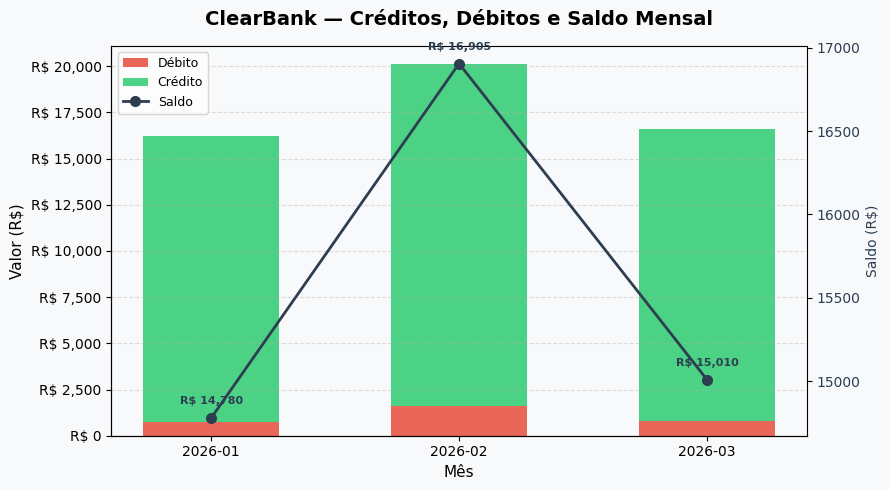


✅ Gráfico salvo: grafico.png


In [10]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import numpy as np

    meses     = list(relatorio["resumo_mensal"].keys())
    creditos  = [relatorio["resumo_mensal"][m]["total_credito"] for m in meses]
    debitos   = [relatorio["resumo_mensal"][m]["total_debito"]  for m in meses]
    saldos    = [relatorio["resumo_mensal"][m]["saldo"]         for m in meses]

    x     = np.arange(len(meses))
    width = 0.55

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#F8F9FA")
    ax.set_facecolor("#F8F9FA")

    # Barras empilhadas
    bars_deb  = ax.bar(x, debitos,  width, label="Débito",  color="#E74C3C", alpha=0.85)
    bars_cred = ax.bar(x, creditos, width, bottom=debitos,  label="Crédito", color="#2ECC71", alpha=0.85)

    # Linha de saldo
    ax2 = ax.twinx()
    ax2.plot(x, saldos, color="#2C3E50", marker="o", linewidth=2,
             markersize=7, label="Saldo", zorder=5)
    ax2.set_ylabel("Saldo (R$)", fontsize=10, color="#2C3E50")
    ax2.tick_params(axis="y", labelcolor="#2C3E50")

    # Rótulos nas barras de saldo
    for xi, saldo in zip(x, saldos):
        ax2.annotate(f"R$ {saldo:,.0f}",
                     xy=(xi, saldo), xytext=(0, 10),
                     textcoords="offset points", ha="center",
                     fontsize=8, color="#2C3E50", fontweight="bold")

    # Formatação do eixo Y principal
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda val, _: f"R$ {val:,.0f}"))

    ax.set_title("ClearBank — Créditos, Débitos e Saldo Mensal",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Mês", fontsize=11)
    ax.set_ylabel("Valor (R$)", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(meses, fontsize=10)

    # Legendas combinadas
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2,
              loc="upper left", fontsize=9, framealpha=0.8)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    plt.savefig(ARQUIVO_GRAFICO, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ Gráfico salvo: {ARQUIVO_GRAFICO}")

except ImportError:
    print("⚠️  matplotlib não está instalado. Execute: pip install matplotlib")


## ✅ 11. Checklist de Entrega

| Item | Status |
|------|--------|
| Leitura CSV com `csv.DictReader` (R1) | ✅ |
| Validação com 5 regras (R2) | ✅ |
| Resumo de limpeza no terminal (R2) | ✅ |
| ≥ 4 funções com responsabilidade única (R3) | ✅ (`ler_transacoes`, `validar_transacao`, `gerar_relatorio`, `identificar_suspeitas`, `salvar_json`, `exibir_relatorio`) |
| `datetime.strptime` e extração de mês (R4) | ✅ |
| Cálculo de intervalo em dias (R4) | ✅ |
| 7 métricas mensais (R5) | ✅ |
| `LIMITE_SUSPEITO` e listagem de suspeitas (R6) | ✅ |
| `relatorio.json` com estrutura correta (R7) | ✅ |
| `try/except` em ≥ 3 situações (R8) | ✅ (abertura CSV · conversão valor · conversão data) |
| Relatório formatado com separadores e R$ (R9) | ✅ |
| Análise com pandas + comparação (RO1) | ✅ |
| `grafico.png` com barras empilhadas (RO2) | ✅ |

> Todos os arquivos gerados: `relatorio.json` · `grafico.png`
